## Summary Standalone Script For testing Purposes

#### 4 main Steps:
- data preparation
- training
- evaluation
- inverse optimization

In [1]:
import numpy as np
#import scipy as sc
import matplotlib.pyplot as plt
import soundfile as sf

## Dataset 

In [2]:
from dataclasses import asdict, dataclass
from collections import defaultdict
from pathlib import Path #system adaptive path handling
import re

PAIR_RE = re.compile(r"seq(?P<seq>\d+)_level_minus(?P<level>[\d.]+)dB_meas(?P<meas>\d+)")
AVERAGED_MIC_RE = re.compile(r"level_minus(?P<level>[\d.]+)dB_mic_aligned_trimmed_avg")

@dataclass()
class Pair:
    key: str
    seq: int
    meas: int
    level_db: float
    loopback_path: str
    mic_path: str
    linear_reference_path: str | None = None
    residual_path: str | None = None



def select_reference_pair(pairs: list[Pair], reference_level_db: float | None) -> Pair:
    if reference_level_db is None:
        return min(pairs, key=lambda pair: pair.level_db)
    candidates = [
        pair for pair in pairs if np.isclose(pair.level_db, reference_level_db)
    ]
    if not candidates:
        available = ", ".join(f"{pair.level_db:g}" for pair in pairs)
        raise ValueError(
            f"Reference level {reference_level_db:g} dB not found. "
            f"Available levels: {available}"
        )
    return candidates[0]


def find_pairs(path, selection_db: list | None = None) -> list[Pair]:
            seq_groups = defaultdict(list)
            db_groups = defaultdict(list)
            for file_path in path.glob("*.wav"):
                name = file_path.stem
                m = re.search(r"seq(?P<seq>\d+)", name)
                if not m:
                    continue
                seq = int(m.group("seq"))
                seq_groups[seq].append((file_path))
            pairs = []
            for seq in sorted(seq_groups):
                files = seq_groups[seq]
                if len(files) < 2:
                    continue
                else: 
                    m = re.search(r"level_minus(?P<level>[\d.]+)dB_meas(?P<meas>\d+)", files[0].stem)
                    level_db = -float(m.group("level"))
                    meas = int(m.group("meas"))
                # try to identify mic vs sweep/recording by name heuristics
                mic_files = [f for f in files if "mic" in f.stem]
                sweep_files = [f for f in files if "sweep" in f.stem or "recorded" in f.stem]
                if mic_files and sweep_files:
                    for mfile in mic_files:
                        for sfile in sweep_files:
                            #pairs.append(dict(seq=seq, mic_file=mfile, sweep_file=sfile, level_db=level_db))
                            
                            pairs.append(Pair(
                                key=f"seq{seq:03d}_minus{abs(level_db):.1f}dB_meas{meas:02d}",
                                seq=seq,
                                meas=meas,
                                level_db=level_db,
                                loopback_path=Path(sfile),
                                mic_path=Path(mfile),
                            ))
                            #print(f"Found pair seq{seq:03d}: mic={mfile.name}, sweep={sfile.name}")
                else:
                    # fallback: pair files arbitrarily if at least two exist
                    for i in range(len(files) - 1):
                        pairs.append((seq, files[i], files[i + 1]))
                    print(f"Seq {seq} has {len(files)} files: {[f.name for f in files]} (no clear mic/sweep split)")
            if selection_db is not None:
                pairs = [p for p in pairs if p.level_db in selection_db]
            # pairs now holds tuples of (seq, mic_path, sweep_path) (or fallback pairings)
            return pairs

#helper functions

def load_mono(path: str | Path) -> tuple[np.ndarray, int]:
    data, sr = sf.read(str(path), dtype="float32", always_2d=False)
    if data.ndim > 1:
        data = np.mean(data, axis=1)
    return np.asarray(data, dtype=np.float32), int(sr)

def rms(signal: np.ndarray, eps: float = 1e-12) -> float:
    return float(np.sqrt(np.mean(np.square(signal, dtype=np.float64))) + eps)

def write_wav(path: str | Path, data: np.ndarray, sr: int, subtype: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    sf.write(str(path), np.asarray(data, dtype=np.float32), sr, subtype=subtype)
    

# Load Pairs from Preprocessed Data Folders
from scaleaudio.training.data import match_training_pairs
def get_prepared_pairs(dir_path: Path):
    sweep_dir= Path.joinpath(dir_path, "input")
    mic_dir = Path.joinpath(dir_path, "measured")
    linref_dir= Path.joinpath(dir_path,"linear")
    res_dir = Path.joinpath(dir_path,"target")
    pairs = []
    for i, p in enumerate(match_training_pairs(sweep_dir, mic_dir)):
        pairs.append( 
        Pair(
            key = p.key,
            seq= i+1,
            meas = 1,
            level_db = p.level_db,
            loopback_path = p.loopback_path,
            mic_path = p.target_path,
            linear_reference_path=Path.joinpath(linref_dir, p.key+'.wav'),
            residual_path=Path.joinpath(res_dir, p.key+'.wav')
            )
        )
    return pairs

# Get pairs from raw data directory, and compute linear Reference and Residual 
def compute_linref_residual_to_pair(pairs: list[Pair], data_path: str):
    # select reference pair for linear scaling
    ref_db= min(pair.level_db for pair in pairs)
    reference_pair = select_reference_pair(pairs, ref_db)
    print(f"Using reference: {reference_pair.key} ({reference_pair.level_db:g} dB)")
    pairs.remove(reference_pair)
    # Scale the reference to target level
    ref_sweep, ref_mic = load_mono(reference_pair.loopback_path)[0], load_mono(reference_pair.mic_path)[0]
    for pair in pairs:
        sweep, sr = load_mono(pair.loopback_path)
        mic_recoding, sr = load_mono(pair.mic_path)
        gain = rms(sweep) / rms(ref_sweep)
        linear_reference = ref_mic * gain

        linear_reference_path = Path.joinpath(data_path, f"linear_reference_sweeps/{pair.key}_linear_reference.wav")
        write_wav(linear_reference_path, linear_reference, sr, "FLOAT")
        pair.linear_reference_path = linear_reference_path

        residual = mic_recoding - linear_reference
        residual_path = Path.joinpath(data_path, f"target_residual/{pair.key}_residual.wav")
        write_wav(residual_path, residual, sr, "FLOAT")
        pair.residual_path = residual_path
    


In [4]:
PAIR_RE = re.compile(
    r"(?P<prefix>.*?seq(?P<seq>\d+)_.+?_level_minus(?P<level>[\d.]+)dB_meas(?P<meas>\d+))_(?P<role>.+)$"
)

def find_music_pairs(path: Path) -> list[Pair]:
    """
    Finds matching mic/reference pairs in raw_measurements.

    Works for:
      - sweeps:      ..._recorded_sweep.wav + ..._mic.wav
      - multitones:  ..._loopback.wav + ..._mic.wav
      - music/etc:   ..._loopback.wav + ..._mic.wav

    If only drive+mic exists, it can fall back to drive.
    """

    path = Path(path)

    # If you pass raw_measurements, search the raw recording folders.
    # If you pass raw_sweeps/raw_multitone/etc directly, search just there.
    if path.name == "raw_measurements":
        wav_files = []
        for subdir in ("raw_sweeps", "raw_multitone", "raw_program_material"):
            wav_files.extend((path / subdir).glob("*.wav"))
    else:
        wav_files = list(path.glob("*.wav"))

    groups = defaultdict(dict)

    for file_path in sorted(wav_files):
        match = PAIR_RE.match(file_path.stem)
        if not match:
            continue

        seq = int(match.group("seq"))
        level_db = -float(match.group("level"))
        meas = int(match.group("meas"))
        role = match.group("role")

        # This key is everything except the final role: mic/loopback/drive/etc.
        base_key = match.group("prefix")

        groups[base_key][role] = file_path
        groups[base_key]["__meta__"] = {
            "seq": seq,
            "level_db": level_db,
            "meas": meas,
        }

    pairs = []

    for base_key, files in sorted(groups.items()):
        meta = files["__meta__"]

        mic_path = files.get("mic")
        if mic_path is None:
            continue

        # Prefer the actual recorded reference signal when available.
        # Sweeps use recorded_sweep, multitones/music usually use loopback.
        loopback_path = (
            files.get("recorded_sweep")
            or files.get("loopback")
            or files.get("drive")
        )

        if loopback_path is None:
            print(
                f"No reference file for seq{meta['seq']:03d}: "
                f"{[k for k in files if k != '__meta__']}"
            )
            continue

        seq = meta["seq"]
        level_db = meta["level_db"]
        meas = meta["meas"]

        pairs.append(
            Pair(
                key=f"seq{seq:03d}_minus{abs(level_db):.1f}dB_meas{meas:02d}",
                seq=seq,
                meas=meas,
                level_db=level_db,
                loopback_path=Path(loopback_path),
                mic_path=Path(mic_path),
            )
        )

    return sorted(pairs, key=lambda p: (p.seq, p.level_db, p.meas))

In [3]:
def correlate(x: np.ndarray, y: np.ndarray, eps: float = 1e-8) -> float:
    x0 = x - x.mean()
    y0 = y - y.mean()
    denom = np.sqrt(np.sum(x0**2) * np.sum(y0**2)) + eps
    return float(np.sum(x0 * y0) / denom)

def align_segments(
    x: np.ndarray,
    y: np.ndarray,
    max_shift: int = 128,
    penalty_lambda: float = 2.0,
    eps: float = 1e-8,
):

    x = np.asarray(x, dtype=np.float32).reshape(-1)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    if x.shape != y.shape:
        raise ValueError(f"Expected same shape, got {x.shape} vs {y.shape}")

    n = len(x)
    if n == 0:
        raise ValueError("Empty segment")

    x0 = x - x.mean()
    y0 = y - y.mean()

    best_lag = 0
    best_score = -np.inf
    corr_vals = []
    for lag in range(-max_shift, max_shift + 1):
        if lag >= 0:
            xs = x0[: n - lag]
            ys = y0[lag:]
        else:
            xs = x0[-lag:]
            ys = y0[: n + lag]

        if len(xs) < max(16, n // 8):
            continue
        corr = correlate(xs, ys)
        corr_vals.append(corr)
        # Strong regularization: penalize larger shifts quadratically.
        lag_penalty = penalty_lambda * (abs(lag) / max_shift) ** 2
        score = corr - lag_penalty

        if score > best_score:
            best_score = score
            best_lag = lag

    if best_lag >= 0:
        x_ = x[: n - best_lag]
        y_ = y[best_lag:]

    else:
        x_ = x[-best_lag:]
        y_ = y[: n + best_lag]
    return x_, y_, best_lag, correlate(x_, y_)

In [4]:
from dataclasses import dataclass
from scipy import signal
from torch.utils.data import Dataset
import numpy as np
import torch
import soundfile as sf


@dataclass(frozen=True)
class AudioFilterConfig:
    mode: str = "none"      # "none", "highpass", "lowpass", "bandpass"
    low_hz: float | None = None
    high_hz: float | None = None
    order: int = 4
    zero_phase: bool = True


def apply_audio_filter(x: np.ndarray, sr: int, config: AudioFilterConfig) -> np.ndarray:
    if config.mode == "none":
        return np.asarray(x, dtype=np.float32)

    nyquist = sr / 2

    if config.mode == "highpass":
        if config.low_hz is None:
            raise ValueError("highpass needs low_hz")
        if not 0 < config.low_hz < nyquist:
            raise ValueError(f"Expected 0 < low_hz < {nyquist}, got {config.low_hz}")
        wn = config.low_hz
        btype = "highpass"

    elif config.mode == "lowpass":
        if config.high_hz is None:
            raise ValueError("lowpass needs high_hz")
        if not 0 < config.high_hz < nyquist:
            raise ValueError(f"Expected 0 < high_hz < {nyquist}, got {config.high_hz}")
        wn = config.high_hz
        btype = "lowpass"

    elif config.mode == "bandpass":
        if config.low_hz is None or config.high_hz is None:
            raise ValueError("bandpass needs low_hz and high_hz")
        if not 0 < config.low_hz < config.high_hz < nyquist:
            raise ValueError(
                f"Expected 0 < low_hz < high_hz < {nyquist}, got "
                f"{config.low_hz}, {config.high_hz}"
            )
        wn = [config.low_hz, config.high_hz]
        btype = "bandpass"

    else:
        raise ValueError(f"Unknown filter mode: {config.mode}")

    sos = signal.butter(
        config.order,
        wn,
        btype=btype,
        fs=sr,
        output="sos",
    )

    if config.zero_phase:
        y = signal.sosfiltfilt(sos, x)
    else:
        y = signal.sosfilt(sos, x)

    return np.asarray(y, dtype=np.float32)



class _SweepSegmentDataset(Dataset):
    def __init__(self, segments):
        self.segments = segments

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        input_signal, target, _ = self.segments[idx]

        return (
            torch.from_numpy(input_signal).unsqueeze(0),
            torch.from_numpy(target).unsqueeze(0)
        )
    def metadata(self, idx):
        _, _, data = self.segments[idx]
        return data

class PreprocessedSweepDataset:
    """Build train/val/test datasets after filtering and residual computation."""
    def __init__(
        self,
        pairs: list[Pair],
        segment_samples: int,
        split_mode: str = "manual",          # "manual" or "random"
        train_keys: list[str] | None = None,
        val_keys: list[str] | None = None,
        test_keys: list[str] | None = None,
        train_fraction: float = 0.7,
        val_fraction: float = 0.15,
        test_fraction: float = 0.15,
        seed: int = 42,
        mode: str = "residual",        # "residual", "mic", "linear_reference", "inverse"
        reference_level_db: float | None = None,
        filter_config: AudioFilterConfig | None = None,
        align_segments: bool = False,
        max_shift: int = 512,
    ):
        self.segment_samples = segment_samples
        self.mode = mode
        self.filter_config = filter_config or AudioFilterConfig(mode="none")
        self.align_segments = align_segments
        if self.align_segments:
            self.alignents = []
        self.reference_pair = select_reference_pair(pairs.copy(), reference_level_db)
        self.max_shift = max_shift
        
        self.train_pairs, self.val_pairs, self.test_pairs = self._make_splits(
            pairs=pairs,
            split_mode=split_mode,
            train_keys=train_keys,
            val_keys=val_keys,
            test_keys=test_keys,
            train_fraction=train_fraction,
            val_fraction=val_fraction,
            test_fraction=test_fraction,
            seed=seed,
        )

        ref_loopback, ref_mic, ref_sr = self._load_filtered_pair(self.reference_pair)
        self.train_segments = self._build_segments(self.train_pairs, ref_loopback, ref_mic, ref_sr)
        self.val_segments = self._build_segments(self.val_pairs, ref_loopback, ref_mic, ref_sr)
        self.test_segments = self._build_segments(self.test_pairs, ref_loopback, ref_mic, ref_sr)

        self.train = _SweepSegmentDataset(self.train_segments)
        self.val = _SweepSegmentDataset(self.val_segments)
        self.test = _SweepSegmentDataset(self.test_segments)

        # Aliases, so both ds.train and ds.train_ds work in experiments.
        self.train_ds = self.train
        self.val_ds = self.val
        self.test_ds = self.test

    def _make_splits(
        self,
        pairs,
        split_mode,
        train_keys,
        val_keys,
        test_keys,
        train_fraction,
        val_fraction,
        test_fraction,
        seed,
    ):
        pairs = [pair for pair in pairs if pair.key != self.reference_pair.key]

        if split_mode == "manual":
            train_keys = train_keys or []
            val_keys = val_keys or []
            test_keys = test_keys or []

            if train_keys:
                train_pairs = [
                    pair for pair in pairs
                    if any(key in pair.key for key in train_keys)
                ]
            else:
                train_pairs = [
                    pair for pair in pairs
                    if not any(key in pair.key for key in val_keys + test_keys)
                ]

            val_pairs = [
                pair for pair in pairs
                if any(key in pair.key for key in val_keys)
            ]
            test_pairs = [
                pair for pair in pairs
                if any(key in pair.key for key in test_keys)
            ]

        elif split_mode == "random":
            total = train_fraction + val_fraction + test_fraction
            if not np.isclose(total, 1.0):
                raise ValueError("train/val/test fractions must sum to 1.0")

            rng = np.random.default_rng(seed)
            shuffled = pairs.copy()
            rng.shuffle(shuffled)

            n_total = len(shuffled)
            n_train = int(train_fraction * n_total)
            n_val = int(val_fraction * n_total)

            train_pairs = shuffled[:n_train]
            val_pairs = shuffled[n_train:n_train + n_val]
            test_pairs = shuffled[n_train + n_val:]

        else:
            raise ValueError("split_mode must be 'manual' or 'random'")

        overlap = (
            {pair.key for pair in train_pairs} & {pair.key for pair in val_pairs}
            or {pair.key for pair in train_pairs} & {pair.key for pair in test_pairs}
            or {pair.key for pair in val_pairs} & {pair.key for pair in test_pairs}
        )
        if overlap:
            raise ValueError(f"Pairs appear in multiple splits: {sorted(overlap)}")

        return train_pairs, val_pairs, test_pairs

    def _load_filtered_pair(self, pair: Pair):
        loopback, sr_loopback = load_mono(pair.loopback_path)
        mic, sr_mic = load_mono(pair.mic_path)

        if sr_loopback != sr_mic:
            raise ValueError(f"Sample rates differ for {pair.key}")

        loopback = apply_audio_filter(loopback, sr_loopback, self.filter_config)
        mic = apply_audio_filter(mic, sr_mic, self.filter_config)

        return loopback, mic, sr_loopback

    def _build_segments(self, split_pairs, ref_loopback, ref_mic, ref_sr):
        segments = []

        for pair in split_pairs:
            loopback, mic, sr = self._load_filtered_pair(pair)

            if sr != ref_sr:
                raise ValueError(f"Sample rate differs from reference for {pair.key}")

            n = min(len(loopback), len(mic), len(ref_loopback), len(ref_mic))
            loopback = loopback[:n]
            mic = mic[:n]
            ref_loopback_used = ref_loopback[:n]
            ref_mic_used = ref_mic[:n]

            gain = rms(loopback) / rms(ref_loopback_used)
            linear_reference = ref_mic_used * gain
            #residual = mic - linear_reference

            if self.mode == "residual":
                input_signal = loopback
                target = np.array([mic, linear_reference]).T
            elif self.mode == "mic":
                input_signal = loopback
                target = mic
            elif self.mode == "linear_reference":
                input_signal = loopback
                target = linear_reference
            elif self.mode == "inverse":
                input_signal = mic
                target = loopback
            else:
                raise ValueError(
                    "target_str must be 'residual', 'mic', 'linear_reference', or 'inverse'"
                )

            n_segments = len(input_signal) // self.segment_samples
            discarded= 0
            for index in range(n_segments):
                start = index * self.segment_samples
                end = start + self.segment_samples

                seg_in = input_signal[start:end].copy()
                seg_tgt = target[start:end].copy()
                if self.mode =="residual":
                    mic_aligned, ref_aligned, lag, score = align_segments(
                        seg_tgt[:, 0],
                        seg_tgt[:, 1],
                        max_shift=self.max_shift,
                        penalty_lambda=2.0,   # increase to 4.0 or 8.0 for even stronger regularization
                    )
                    # align input
                    if lag > 0:
                        seg_in = seg_in[:-lag]
                    elif lag < 0:
                        seg_in = seg_in[-lag:]
                    # only keep good segments
                    if score > 0.96:
                        # cropp all samples to same legth
                        seg_in = seg_in[:self.segment_samples-self.max_shift]
                        mic_aligned = mic_aligned[:self.segment_samples-self.max_shift]
                        ref_aligned = ref_aligned[:self.segment_samples-self.max_shift]

                        data = {
                            "level_db": pair.level_db,
                            "lag": lag,
                            "corr_score": score,
                            "mic_aligned": mic_aligned,
                            "ref_aligned": ref_aligned,
                        }
                        residual = mic_aligned-ref_aligned
                        if len(seg_in) != len(residual):
                            print(f"Warning: aligned segment shape mismatch for {pair.key} at index {index}: "
                                f"input {seg_in.shape}, residual {residual.shape}, lag {lag}, score {score:.4f}")

                        segments.append((seg_in, residual, data))
                    else: 
                        discarded += 1

                    
                else:
                    segments.append((seg_in, seg_tgt, {"level_db":np.float32(pair.level_db)}))
                    
            if discarded >0:
                        print(f"discarded {discarded} segments for {pair.key}")
        return segments

    def summary(self):
        print(f"Reference: {self.reference_pair.key} ({self.reference_pair.level_db:g} dB)")
        print(f"Mode: {self.mode}")
        print(f"Filter: {self.filter_config}")
        print(f"Train pairs: {[pair.level_db for pair in self.train_pairs]}")
        print(f"Val pairs:   {[pair.level_db for pair in self.val_pairs]}")
        print(f"Test pairs:  {[pair.level_db for pair in self.test_pairs]}")
        print(f"Train segments: {len(self.train)}")
        print(f"Val segments:   {len(self.val)}")
        print(f"Test segments:  {len(self.test)}")
    

def get_datasets(pairs, val_keys: list[str], test_keys: list[str], segment_length_ms: int = 1000):
    sr = 48000
    segment_length = int(sr * segment_length_ms / 1000)

    filter_config = AudioFilterConfig(
        mode="highpass",
        low_hz=80.0,
        order=4,
        zero_phase=True,
    )

    ds = PreprocessedSweepDataset(
        pairs,
        segment_length,
        split_mode="manual",
        val_keys=val_keys,
        test_keys=test_keys,
        mode="residual",
        reference_level_db=-34.0,
        filter_config=filter_config,
    )
    return ds


In [14]:
test_pair = find_pairs(Path("raw_measurements/aligned_sweeps"), selection_db=[-33, -9])
len(test_pair), test_pair

(4,
 [Pair(key='seq010_minus9.0dB_meas02', seq=10, meas=2, level_db=-9.0, loopback_path=WindowsPath('raw_measurements/aligned_sweeps/seq010_level_minus9.0dB_meas02_recorded_sweep_trimmed.wav'), mic_path=WindowsPath('raw_measurements/aligned_sweeps/seq010_level_minus9.0dB_meas02_mic_aligned_trimmed.wav'), linear_reference_path=None, residual_path=None),
  Pair(key='seq039_minus33.0dB_meas01', seq=39, meas=1, level_db=-33.0, loopback_path=WindowsPath('raw_measurements/aligned_sweeps/seq039_level_minus33.0dB_meas01_recorded_sweep_trimmed.wav'), mic_path=WindowsPath('raw_measurements/aligned_sweeps/seq039_level_minus33.0dB_meas01_mic_aligned_trimmed.wav'), linear_reference_path=None, residual_path=None),
  Pair(key='seq041_minus9.0dB_meas01', seq=41, meas=1, level_db=-9.0, loopback_path=WindowsPath('raw_measurements/aligned_sweeps/seq041_level_minus9.0dB_meas01_recorded_sweep_trimmed.wav'), mic_path=WindowsPath('raw_measurements/aligned_sweeps/seq041_level_minus9.0dB_meas01_mic_aligned_tri

In [210]:
filter_config = AudioFilterConfig(
    mode="lowpass",
    low_hz=20.0,
    high_hz=1000,
    order=4,
    zero_phase=True,
)

test_ds = PreprocessedSweepDataset(
    test_pair,
    200*48,
    split_mode="manual",
    mode="residual",
    reference_level_db=None,
    filter_config=filter_config,
)

discarded 2 segments for seq010_minus9.0dB_meas02
discarded 2 segments for seq041_minus9.0dB_meas01
discarded 3 segments for seq051_minus33.0dB_meas02


In [121]:
test_ds.train[1][0].shape, test_ds.train[1][1].shape

(torch.Size([1, 9551]), torch.Size([1, 9551]))

(np.int64(0), np.float64(0.965477466583252))

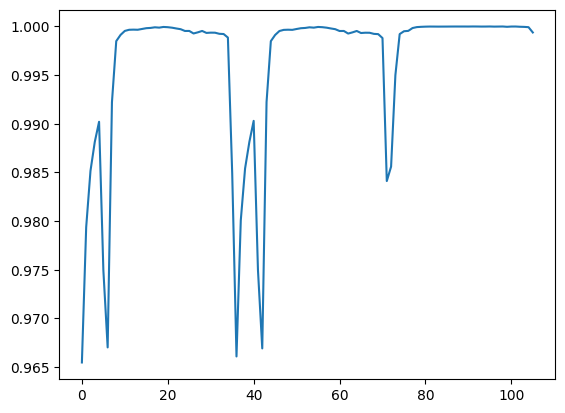

In [211]:
scores = [test_ds.train.metadata(i)["corr_score"] for i in range(len(test_ds.train))]
lags = [test_ds.train.metadata(i)["lag"] for i in range(len(test_ds.train))]
scores.pop()
plt.plot(scores)
np.argmin(scores), np.min(scores)

In [212]:
test_loader = DataLoader(
    test_ds.train, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
for batch_idx, (input, target) in enumerate(test_loader):
    pass

In [ ]:
n = len(x)
x0 = x.copy()
lag = 27
if lag >= 0:
    x0 = x[:-lag]
else:
    x0 = x[-lag:]
len(x0), len(y)

(9573,
 9573,
 array([ True,  True,  True, ...,  True,  True,  True], shape=(9573,)))

(9574, 9574, -26, 0.965477466583252)

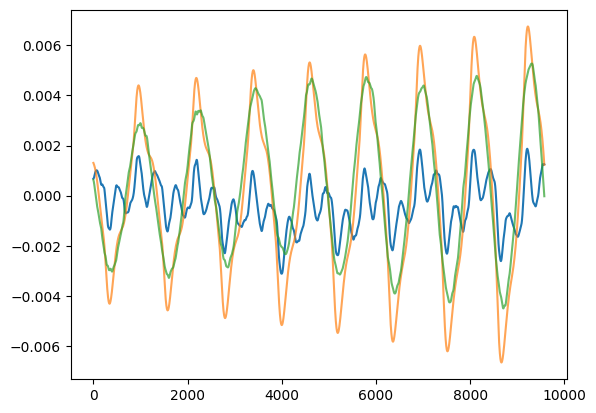

In [203]:
idx =  0
x,y = test_ds.train[idx]
data = test_ds.train.metadata(idx)
x = x.numpy().flatten()
y = y.numpy().flatten()
mic = data["mic_aligned"]
ref = data["ref_aligned"]
db = data["level_db"]
lag = data["lag"]
score = data["corr_score"]
if lag >= 0:
    x0 = x[:-lag]
else:
    x0 = x[-lag:]
#plt.plot(x0)
plt.plot(y)
plt.plot(mic, alpha=0.7)
plt.plot(ref, alpha=0.7)
len(x), len(y), lag, score

In [189]:
data

np.float32(-9.0)

In [ ]:
x = test_ds.train[3][0].numpy().flatten()
y = test_ds.train[3][1].numpy().flatten()*2
max_shift =2280
x_, y_, lag, score, correlations = align_segments(x, y, max_shift=max_shift, penalty_lambda=2)

print(lag, score)
n = len(x)

print(correlate(x_, y_))
plt.plot(np.arange(-max_shift, max_shift+1),correlations)
plt.vlines(lag, min(correlations), max(correlations), colors='r', linestyles='dashed', label=f'Best Lag: {lag} samples')
plt.figure()
plt.plot(x_)
plt.plot(y_)
plt.figure()
plt.plot(x)
plt.plot(y)

ValueError: not enough values to unpack (expected 5, got 4)

## Model Architecture

In [5]:
import torch.nn as nn
import torch.nn.functional as functional


class CausalConv1d(nn.Module):
    """Causal 1D convolution with dilation."""

    def __init__(self, in_ch: int, out_ch: int, kernel_size: int, dilation: int):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation, bias=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = functional.pad(x, (self.padding, 0))
        return self.conv(x)


class TCNBlock(nn.Module):
    def __init__(self, ch: int, kernel_size: int, dilation: int):
        super().__init__()
        self.conv1 = CausalConv1d(ch, ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(ch, ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(ch)
        self.norm2 = nn.LayerNorm(ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        h = self.conv1(x)
        h = self.norm1(h.transpose(1, 2)).transpose(1, 2)
        h = torch.tanh(h)
        h = self.conv2(h)
        h = self.norm2(h.transpose(1, 2)).transpose(1, 2)
        h = torch.tanh(h)
        return h + residual

class MicroTCN(nn.Module):
    """
    Small causal TCN for mono waveform modeling.

    Receptive field = 1 + (kernel_size - 1) * sum(2 ** i for i in n_blocks)
    """

    def __init__(
        self,
        n_blocks: int = 6,
        kernel_size: int = 13,
        channels: int = 16,
        input_channels: int = 1,
        sr: int = 48000,
        print_summary: bool = True,
    ):
        super().__init__()
        dilations = [2**i for i in range(n_blocks)]
        self.receptive_field = 1 + (kernel_size - 1) * sum(dilations)
        if print_summary:
            print(
                f"  Receptive Field: {self.receptive_field} Samples "
                f"({self.receptive_field / sr * 1000:.1f} ms @ {sr}Hz)"
            )

        self.input_proj = nn.Conv1d(input_channels, channels, 1)
        self.blocks = nn.ModuleList(
            [TCNBlock(channels, kernel_size, dilation) for dilation in dilations]
        )
        self.output_proj = nn.Conv1d(channels, 1, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.output_proj(h)
    




## Loss Function

In [6]:
import torch
import torch.nn.functional as F


def _reduce_loss(loss, reduction="mean"):
    if reduction == "none":
        return loss
    if reduction == "mean":
        return loss.mean()
    raise ValueError(f"Unsupported reduction: {reduction}")

def trim_loss_start(pred, target, skip_samples: int = 0):
    if skip_samples <= 0:
        return pred, target

    if pred.shape != target.shape:
        raise ValueError(f"pred and target shape mismatch: {pred.shape} vs {target.shape}")

    if skip_samples >= pred.shape[-1]:
        raise ValueError(
            f"skip_samples={skip_samples} must be smaller than segment length={pred.shape[-1]}"
        )

    return pred[..., skip_samples:], target[..., skip_samples:]


# mean squared Loss
def esr_loss(pred, target, eps=1e-8, reduction="mean"):
    loss = torch.mean((pred - target) ** 2, dim=(1, 2)) / (
        torch.mean(target**2, dim=(1, 2)) + eps
    )
    return _reduce_loss(loss, reduction)

# mean loss
def dc_loss(pred, target, reduction="mean"):
    loss = torch.abs(pred.mean(dim=(1, 2)) - target.mean(dim=(1, 2)))
    return _reduce_loss(loss, reduction)


def stft_mag_loss(pred, target, n_fft, hop_length=None, win_length=None, eps=1e-8):
    hop_length = hop_length or n_fft // 4
    win_length = win_length or n_fft

    b, c, n = pred.shape
    pred_flat = pred.reshape(b * c, n)
    target_flat = target.reshape(b * c, n)

    window = torch.hann_window(win_length, device=pred.device, dtype=pred.dtype)

    pred_spec = torch.stft(
        pred_flat,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=window,
        return_complex=True,
        center=True,
    )

    target_spec = torch.stft(
        target_flat,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=window,
        return_complex=True,
        center=True,
    )

    pred_mag = pred_spec.abs()
    target_mag = target_spec.abs()

    log_mag_loss = torch.mean(
        torch.abs(torch.log(pred_mag + eps) - torch.log(target_mag + eps)),
        dim=(1, 2),
    )

    sc_loss = torch.linalg.vector_norm(target_mag - pred_mag, dim=(1, 2)) / (
        torch.linalg.vector_norm(target_mag, dim=(1, 2)) + eps
    )

    loss = log_mag_loss + sc_loss
    return loss.reshape(b, c).mean(dim=1)


def multi_resolution_stft_loss(
    pred,
    target,
    resolutions=((512, 128, 512), (1024, 256, 1024), (2048, 512, 2048)),
    reduction="mean",
):
    losses = [
        stft_mag_loss(
            pred,
            target,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
        )
        for n_fft, hop_length, win_length in resolutions
    ]
    loss = torch.stack(losses, dim=0).mean(dim=0)
    return _reduce_loss(loss, reduction)


def harmonic_distortion_loss(
    pred,
    target,
    sample_rate,
    fundamental_freq=None,
    num_harmonics=8,
    n_fft=None,
    eps=1e-8,
    reduction="mean",
):
    if pred.ndim != 3 or target.ndim != 3:
        raise ValueError("Expected pred and target shape [batch, channels, samples].")

    b, c, n = pred.shape
    n_fft = n_fft or int(2 ** torch.ceil(torch.log2(torch.tensor(n))).item())

    window = torch.hann_window(n, device=pred.device, dtype=pred.dtype).view(1, 1, -1)

    pred_mag = torch.fft.rfft(pred * window, n=n_fft, dim=-1).abs()
    target_mag = torch.fft.rfft(target * window, n=n_fft, dim=-1).abs()

    freq_res = sample_rate / n_fft

    if fundamental_freq is None:
        search_bins = max(2, int((sample_rate * 0.45) / freq_res))
        f0_bin = target_mag[..., 1:search_bins].argmax(dim=-1) + 1
    else:
        f0_bin = torch.full(
            (b, c),
            int(round(fundamental_freq / freq_res)),
            device=pred.device,
            dtype=torch.long,
        )

    harmonic_bins = []
    max_bin = pred_mag.shape[-1] - 1

    for h in range(2, num_harmonics + 1):
        bins = torch.clamp(f0_bin * h, max=max_bin)
        harmonic_bins.append(bins)

    harmonic_bins = torch.stack(harmonic_bins, dim=-1)

    pred_harmonics = torch.gather(pred_mag, -1, harmonic_bins)
    target_harmonics = torch.gather(target_mag, -1, harmonic_bins)

    pred_f0 = torch.gather(pred_mag, -1, f0_bin.unsqueeze(-1))
    target_f0 = torch.gather(target_mag, -1, f0_bin.unsqueeze(-1))

    pred_ratio = pred_harmonics / (pred_f0 + eps)
    target_ratio = target_harmonics / (target_f0 + eps)

    loss = torch.mean(
        torch.abs(torch.log(pred_ratio + eps) - torch.log(target_ratio + eps)),
        dim=(1, 2),
    )

    return _reduce_loss(loss, reduction)
def mse_loss(pred, target, reduction="mean"):
    loss = torch.mean((pred - target) ** 2, dim=(1, 2))
    return _reduce_loss(loss, reduction)


def norm_mse_loss(pred, target, reduction="mean"):
    loss = torch.mean((pred - target) ** 2, dim=(1, 2)) / torch.sqrt(torch.mean(target**2, dim=(1, 2)) + 1e-8)
    return _reduce_loss(loss, reduction)


def combined_loss(
    pred,
    target,
    sample_rate,
    trim_start=0,
    alpha=0.2,
    base_weight=1.0,
    mrstft_weight=0.5,
    harmonic_weight=0,
    mrstft_resolutions=((512, 128, 512), (1024, 256, 1024), (2048, 512, 2048)),
    fundamental_freq=None,
    num_harmonics=5,
    reduction="mean",
):
    
    pred, target = trim_loss_start(pred, target, trim_start)

    base = esr_loss(pred, target, reduction="none") + alpha * dc_loss(pred, target, reduction="none")
    mrstft = multi_resolution_stft_loss(
        pred,
        target,
        resolutions=mrstft_resolutions,
        reduction="none",
    )
    if harmonic_weight > 0:
        harmonic = harmonic_distortion_loss(
            pred,
            target,
            sample_rate=sample_rate,
            fundamental_freq=fundamental_freq,
            num_harmonics=num_harmonics,
            reduction="none",
        )
    else:
        harmonic = torch.zeros_like(mrstft)

    loss = base_weight * base + mrstft_weight * mrstft + harmonic_weight * harmonic
 

    loss_summary = {
        'total': loss,
        'base': base,
        'mrstft': mrstft,
        'harmonic':harmonic
    }
    return _reduce_loss(loss, reduction), loss_summary


## Training

In [13]:
from torch.utils.data import DataLoader
import time
def run_training_epoch(
    model: MicroTCN,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    sample_rate: int,
    curr_epoch: int = None,
    #config: dict,
    return_breakdown: bool = False,
) -> float | dict[str, float]:
    model.train()
    totals = {
        "total": 0.0,
        "base": 0.0,
        "mrstft": 0.0,
        "harmonic": 0.0,
    }
    rf = model.receptive_field
    loss_history = []
    
    for batch_idx, (input, target) in enumerate(loader):
        batch_start = time.time()
        input, target = input.to(device), target.to(device)
        optimizer.zero_grad()
        pred = model(input)
        loss, breakdown = combined_loss(pred, target, reduction="mean", sample_rate=sample_rate,trim_start=rf) # ERS + DC loss
        # main uses weighted loss:  compose_training_loss()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_history.append(loss.item())

        for key in totals.keys():
            totals[key] += float(breakdown[key].mean())
        
        # Loading bar
        progress = (batch_idx+1) / len(loader)
        bar_length = 30
        filled = int(bar_length * progress)
        bar = 'â–ˆ' * filled + '-' * (bar_length - filled)

        elapsed = time.time() - batch_start
        print(
            f"\r[Curr] epoch {curr_epoch} | {bar} | {batch_idx+1}/{len(loader)} | "
            f"loss: {loss:.2f} | "
            f"time: {elapsed:.1f} s/batch ", end=''
        )

    summary = {key: value / len(loader) for key, value in totals.items()}
    if return_breakdown:
        return summary
    return summary["total"]

def evaluate_model(
    model: MicroTCN,
    loader: DataLoader,
    device: torch.device,
    #config: dict,
    sample_rate: int, 
    return_breakdown: bool = False,
) -> float | dict[str, float]:
    model.eval()
    totals = {
        "total": 0.0,
        "base": 0.0,
        "mrstft": 0.0,
        "harmonic": 0.0,
    }
    
    with torch.no_grad():
        rf = model.receptive_field
        val_loss_history = []
        for input, target in loader:
            input, target = input.to(device), target.to(device)
            pred = model(input)
            val_loss, breakdown = combined_loss(pred, target, reduction='mean', sample_rate=sample_rate, trim_start=rf)
   
            for key in totals.keys():
                totals[key] += float(breakdown[key].mean())

    summary = {key: value / len(loader) for key, value in totals.items()}
    if return_breakdown:
        return summary
    return summary["total"]

In [8]:
# Training loop 
import time
from scaleaudio.inference import select_device


# model parameters 
N_BLOCKS = 8
KERNEL_SIZE = 9
CHANNELS = 16
# Training parameters
SEG_LENGTH_MS = 400
BATCH_SIZE = 4
EPOCHS = 100
LR = 2.5e-6
EARLY_STOPPING = 10
started_at = time.strftime("%Y-%m-%dT%H:%M:%S%z")
device = select_device()

print("[1/5] Lade Dateipaare...")

# Get Pairs 
data_path = Path("raw_measurements/aligned_sweeps")
pairs = find_pairs(data_path)
#pairs = find_pairs(Path("raw_measurements/raw_multitone"))
#pairs = find_pairs(Path("raw_measurements/raw_program_material"))
#pairs = get_prepared_pairs(Path("data/prepared/scaled_mic_20260424/refm34_avgmic")) 
print(f" {len(pairs)} Paare gefunden: {[pair.key for pair in pairs]}")

print("[2/5] Erstelle Datasets...")
# Get Datasets 
val_keys = [pair.key for pair in pairs if pair.level_db in [-10, -12, -18, -24] and pair.meas == np.random.choice([1, 2])]
test_keys = [pair.key for pair in pairs if pair.level_db in [] and pair.meas == 1]
sr = 48000
segment_length = int(sr * SEG_LENGTH_MS / 1000)

filter_config = AudioFilterConfig(
    mode="lowpass",
    low_hz=20.0,
    high_hz=1000,
    order=4,
    zero_phase=True,
)

ds = PreprocessedSweepDataset(
    pairs,
    segment_length,
    split_mode="manual",
    val_keys=val_keys,
    test_keys=test_keys,
    mode="residual",
    reference_level_db=None,
    filter_config=filter_config,
)
ds.summary()

[1/5] Lade Dateipaare...
 52 Paare gefunden: ['seq001_minus27.0dB_meas02', 'seq002_minus31.0dB_meas01', 'seq003_minus22.0dB_meas01', 'seq004_minus15.0dB_meas01', 'seq005_minus12.0dB_meas02', 'seq006_minus19.0dB_meas02', 'seq007_minus17.0dB_meas01', 'seq008_minus18.0dB_meas02', 'seq009_minus16.0dB_meas02', 'seq010_minus9.0dB_meas02', 'seq011_minus24.0dB_meas01', 'seq012_minus16.0dB_meas01', 'seq013_minus25.0dB_meas01', 'seq014_minus18.0dB_meas01', 'seq015_minus29.0dB_meas01', 'seq016_minus19.0dB_meas01', 'seq017_minus21.0dB_meas02', 'seq018_minus13.0dB_meas01', 'seq019_minus26.0dB_meas02', 'seq020_minus32.0dB_meas01', 'seq021_minus34.0dB_meas02', 'seq022_minus22.0dB_meas02', 'seq023_minus31.0dB_meas02', 'seq024_minus26.0dB_meas01', 'seq025_minus32.0dB_meas02', 'seq026_minus13.0dB_meas02', 'seq027_minus27.0dB_meas01', 'seq028_minus23.0dB_meas02', 'seq029_minus17.0dB_meas02', 'seq030_minus10.0dB_meas02', 'seq031_minus15.0dB_meas02', 'seq032_minus10.0dB_meas01', 'seq033_minus24.0dB_meas02'

In [10]:
ds.summary()

Reference: seq021_minus34.0dB_meas02 (-34 dB)
Mode: residual
Filter: AudioFilterConfig(mode='lowpass', low_hz=20.0, high_hz=1000, order=4, zero_phase=True)
Train pairs: [-27.0, -31.0, -22.0, -15.0, -19.0, -17.0, -18.0, -16.0, -9.0, -24.0, -16.0, -25.0, -18.0, -29.0, -19.0, -21.0, -13.0, -26.0, -32.0, -22.0, -31.0, -26.0, -32.0, -13.0, -27.0, -23.0, -17.0, -10.0, -15.0, -10.0, -11.0, -20.0, -20.0, -21.0, -14.0, -33.0, -23.0, -9.0, -25.0, -11.0, -14.0, -12.0, -30.0, -28.0, -30.0, -29.0, -28.0, -33.0, -34.0]
Val pairs:   [-12.0, -24.0]
Test pairs:  []
Train segments: 880
Val segments:   36
Test segments:  0


In [14]:


print("[3/5] Erstelle Modell...")

pin_memory = device.type == "cuda"
train_loader = DataLoader(
    ds.train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    ds.val, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    ds.test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)



model = MicroTCN(
    n_blocks=N_BLOCKS,
    kernel_size=KERNEL_SIZE,
    channels=CHANNELS,
    input_channels=1,
    sr=sr,
).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=6, factor=0.5, min_lr=1e-7
)

print("[4/5] Training...\n")
train_losses, val_losses = [], []
history_rows: list[dict] = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    lr = float(optimizer.param_groups[0]["lr"])
    train_summary = run_training_epoch(
        model,
        train_loader,
        optimizer,
        device,
        sample_rate=sr,
        curr_epoch=epoch,
        return_breakdown=True,
    )

    #train_summary = evaluate_model(
    #    model,
    #    train_loader,
    #    device,
    #    sample_rate=sr,
    #    return_breakdown=True,
    #)
    #assert not isinstance(train_summary, float)
    val_summary = evaluate_model(
        model,
        val_loader,
        device,
        sample_rate=sr,
        return_breakdown=True,
    )
    assert not isinstance(val_summary, float)

    scheduler.step(val_summary['total'])
    train_losses.append(train_summary["total"])
    val_losses.append(val_summary['total'])
    history_rows.append(
        {
            "epoch": epoch,
            "lr": lr,
            "train": {
                "total": train_summary['total'],
                "base" : train_summary['base'],
                "mrstft": train_summary['mrstft'],
                "harmonic": train_summary['harmonic']
            },
            "val": {
                "total": val_summary['total'],
                "base" : val_summary['base'],
                "mrstft": val_summary['mrstft'],
                "harmonic": val_summary['harmonic']
            }
        }
    )
    if val_summary['total'] < best_val_loss:
        best_val_loss = val_summary['total']
        best_epoch = epoch
        patience = 0
        torch.save(model.state_dict(), "real_mvp_dump/best_model.pt")
    else:
        patience +=1
    if patience > EARLY_STOPPING:
        print(f"Stopping at Epoch {epoch}, best ValÂ {best_val_loss} at Epoch {best_epoch}")
        break

    epoch_time = time.time() - epoch_start
    best = "â˜†" if epoch == best_epoch else ""
    print(
    f"\n epoch {epoch}/{EPOCHS} done | "
    f"train loss {train_summary['total']:.3f} | val loss {val_summary['total']:.3f} {best} | "
    f"stft/base: {val_summary['mrstft']:.2f} / {val_summary['base']:.2f} | lr {lr:.1e} | "
    f"time {epoch_time:.2f}s ")



[3/5] Erstelle Modell...
  Receptive Field: 2041 Samples (42.5 ms @ 48000Hz)
[4/5] Training...



C:\Users\janni\AppData\Local\Temp\ipykernel_61896\4120482055.py:36: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  totals[key] += float(breakdown[key].mean())


[Curr] epoch 1 | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ | 220/220 | loss: 9712.85 | time: 0.0 s/batch    
 epoch 1/100 done | train loss 5524965.442 | val loss 13789.472 â˜† | stft/base: 117.65 / 13730.65 | lr 2.5e-06 | time 9.45s 
[Curr] epoch 2 | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ | 220/220 | loss: 23401.47 | time: 0.0 s/batch 
 epoch 2/100 done | train loss 14062.256 | val loss 4971.588 â˜† | stft/base: 71.46 / 4935.86 | lr 2.5e-06 | time 7.55s 
[Curr] epoch 3 | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ | 220/220 | loss: 7167.38 | time: 0.0 s/batch  
 epoch 3/100 done | train loss 6239.998 | val loss 2356.310 â˜† | stft/base: 49.70 / 2331.46 | lr 2.5e-06 | time 7.50s 
[Curr] epoch 4 | â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ | 220/220 | loss: 1869.82 | time: 0.0 s/batch 
 epoch 4

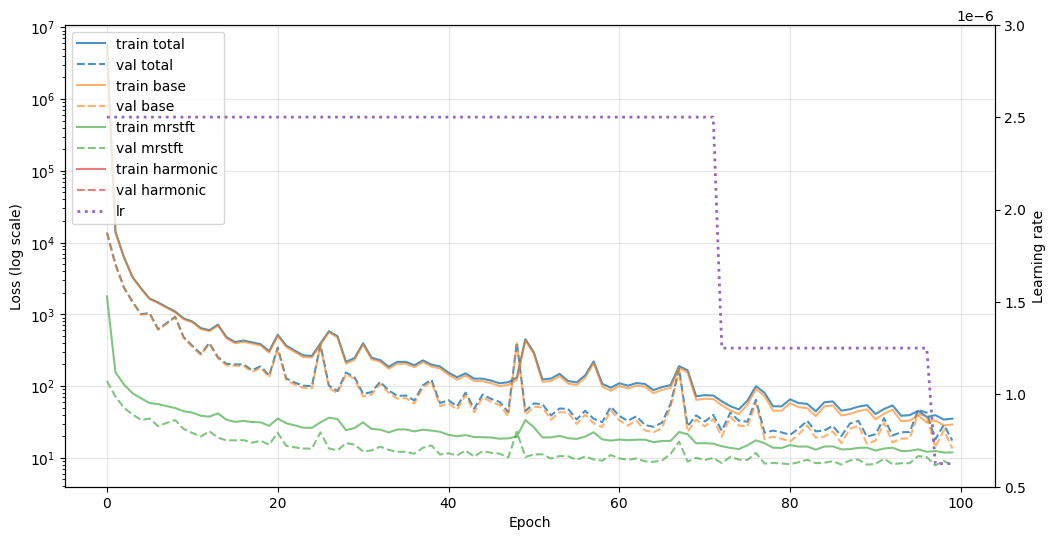

In [15]:
train_curve = np.array([h['train']['total'] for h in history_rows])
val_curve = np.array([h['val']['total'] for h in history_rows])
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_yscale('log')

ax.plot(train_curve, label='train total', alpha=0.8, color='tab:blue', linestyle='-')
ax.plot(val_curve, label='val total', alpha=0.8, color='tab:blue', linestyle='--')
ax.plot([h['train']['base'] for h in history_rows], label='train base', alpha=0.6, color='tab:orange', linestyle='-')
ax.plot([h['val']['base'] for h in history_rows], label='val base', alpha=0.6, color='tab:orange', linestyle='--')
ax.plot([h['train']['mrstft'] for h in history_rows], label='train mrstft', alpha=0.6, color='tab:green', linestyle='-')
ax.plot([h['val']['mrstft'] for h in history_rows], label='val mrstft', alpha=0.6, color='tab:green', linestyle='--')
ax.plot([h['train']['harmonic'] for h in history_rows], label='train harmonic', alpha=0.6, color='tab:red', linestyle='-')
ax.plot([h['val']['harmonic'] for h in history_rows], label='val harmonic', alpha=0.6, color='tab:red', linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.grid(True, alpha=0.3)

ax2 = ax.twinx()
lr_curve = np.array([h['lr'] for h in history_rows])
ax2.plot(lr_curve, label='lr', color='tab:purple', linestyle=':', linewidth=2)
ax2.set_ylabel('Learning rate')
ax2.set_yscale('linear')
ax2.set_ylim(lr_curve.min() * 0.8, lr_curve.max() * 1.2)

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')




In [18]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_random_dataset_samples(
    ds,
    model = None,
    split=None,          # "train", "val", or "test"
    n_samples=3,
    level_db: list | None = None,
    idx_range: tuple[int, int] | None = None,
    sample_rate=48000,
    device=None,
    seed=None,
    trim_start=0,
):
    if seed is not None:
        random.seed(seed)
    if split:
        dataset = {
            "train": ds.train,
            "val": ds.val,
            "test": ds.test,
        }[split]
    else:
        dataset = ds.train + ds.val + ds.test
        split = "dataset"

    if level_db:
        dataset = [s for s in dataset if s[2] in level_db]

    if idx_range:
        dataset = dataset[idx_range[0]:idx_range[1]]
        
    if model:
        if device is None:
            device = next(model.parameters()).device
        model.eval()
        

    indices = random.sample(
        range(len(dataset)),
        k=min(n_samples, len(dataset)),
    )

    for idx in indices:
        input_signal, target= dataset[idx]
        data = dataset.metadata(idx)
        level_db = data["level_db"]
        lag = data["lag"]

        input_batch = input_signal.unsqueeze(0).to(device)
        target_batch = target.unsqueeze(0).to(device)
        if model:
            with torch.no_grad():
                pred_batch = model(input_batch)

                total_loss, breakdown = combined_loss(
                    pred_batch,
                    target_batch,
                    sample_rate=sample_rate,
                    reduction="none",
                    trim_start=trim_start,
                )

        input_np = input_signal.squeeze().cpu().numpy()[trim_start:]
        target_np = target.squeeze().cpu().numpy()[trim_start:]
        if model:
            pred_np = pred_batch.squeeze().cpu().numpy()[trim_start:]
            loss_info = {
            "total": float(total_loss.item()),
            "base": float(breakdown["base"].item()),
            "mrstft": float(breakdown["mrstft"].item()),
            "harmonic": float(breakdown["harmonic"].item()),
            }
        t = np.arange(len(input_np)) / sample_rate



        input_rms = float(np.sqrt(np.mean(input_np ** 2)))
        target_rms = float(np.sqrt(np.mean(target_np ** 2)))
        if model:
            pred_rms = float(np.sqrt(np.mean(pred_np ** 2)))
            err_rms = float(np.sqrt(np.mean((pred_np - target_np) ** 2)))

        fig, axes = plt.subplots(
            2,
            1,
            figsize=(13, 6),
            sharex=True,
            constrained_layout=True,
        )

        axes[0].plot(t, input_np, linewidth=0.8)
        axes[0].set_title(
            f"{split} sample idx={idx} | level={float(level_db):.1f} dB | "
            f"input RMS={input_rms:.4g}| alignment {lag}"
        )
        axes[0].set_ylabel("Input")

        axes[1].plot(t, target_np, label="target", linewidth=0.9)

        
        if model:
            axes[1].plot(t, pred_np, label="prediction", linewidth=0.9, alpha=0.8)
            axes[1].set_title(
                f"loss={loss_info['total']:.4f} | "
                f"base={loss_info['base']:.4f} | "
                f"mrstft={loss_info['mrstft']:.4f} | "
                f"harmonic={loss_info['harmonic']:.4f} | "
                f"target RMS={target_rms:.4g} | pred RMS={pred_rms:.4g} | err RMS={err_rms:.4g}"
            )

        axes[1].set_xlabel("Time [s]")
        axes[1].set_ylabel("Output")
        axes[1].legend(loc="upper right")

        plt.show()


In [ ]:
t,i = next(iter(train_loader))
# plot the first sample from the validation batch
input_batch, target_batch = t, i

sample_idx = 0
input_signal = input_batch[sample_idx, 0].cpu().numpy()
target_signal = target_batch[sample_idx, 0].cpu().numpy()
time_axis = np.arange(input_signal.shape[0]) / sr

plt.figure(figsize=(12, 5))
plt.plot(time_axis, input_signal, label="input")
plt.plot(time_axis, target_signal, label="target", alpha=0.7)
plt.title(f"Validation batch sample {sample_idx} | level {float(levels_db[sample_idx]):.1f} dB")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

ValueError: not enough values to unpack (expected 3, got 2)

In [ ]:
# unprocessed ds 
# Get Datasets 
#val_keys = [pair.key for pair in pairs if pair.level_db in [-9, -14, -19, -24, -29, -33] and pair.meas == 2]
#test_keys = [pair.key for pair in pairs if pair.level_db in [] and pair.meas == 1]
sr = 48000
segment_length = int(sr * SEG_LENGTH_MS / 1000)


unfiltered_ds = PreprocessedSweepDataset(
    pairs,
    segment_length,
    split_mode="manual",
    #val_keys=val_keys,
    #test_keys=test_keys,
    mode="inverse",
    reference_level_db=-34.0,
    filter_config=AudioFilterConfig(mode="none"),
)

AttributeError: 'tuple' object has no attribute 'level_db'

In [ ]:
ds_music = PreprocessedSweepDataset(
    pairs2, # music
    segment_length,
    split_mode="manual",
    val_keys=[],
    test_keys=[],
    mode="residual",
    reference_level_db=None,
    filter_config=filter_config,
)
ds_music.summary()

Reference: seq001_minus34.0dB_meas01 (-34 dB)
Mode: mic
Filter: AudioFilterConfig(mode='lowpass', low_hz=20.0, high_hz=1000, order=4, zero_phase=True)
Train pairs: [-34.0, -34.0, -34.0, -34.0, -34.0, -30.0, -30.0, -30.0, -30.0, -30.0, -30.0, -26.0, -26.0, -26.0, -26.0, -26.0, -26.0, -24.0, -24.0, -24.0, -24.0, -24.0, -24.0]
Val pairs:   []
Test pairs:  []
Train segments: 299
Val segments:   0
Test segments:  0


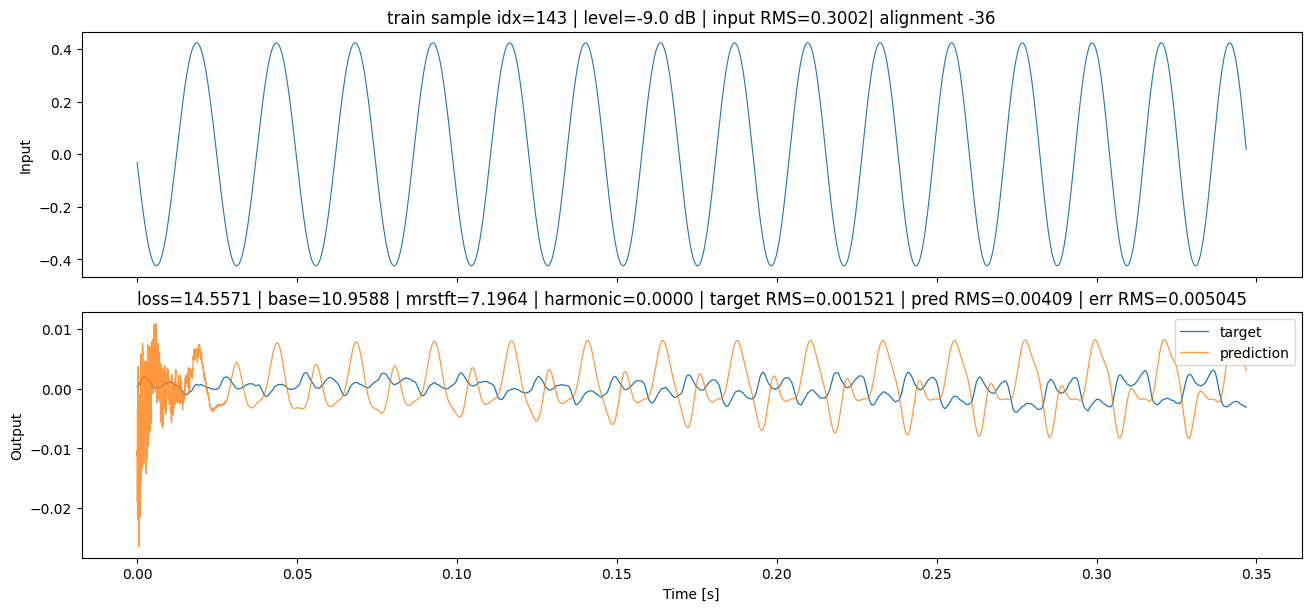

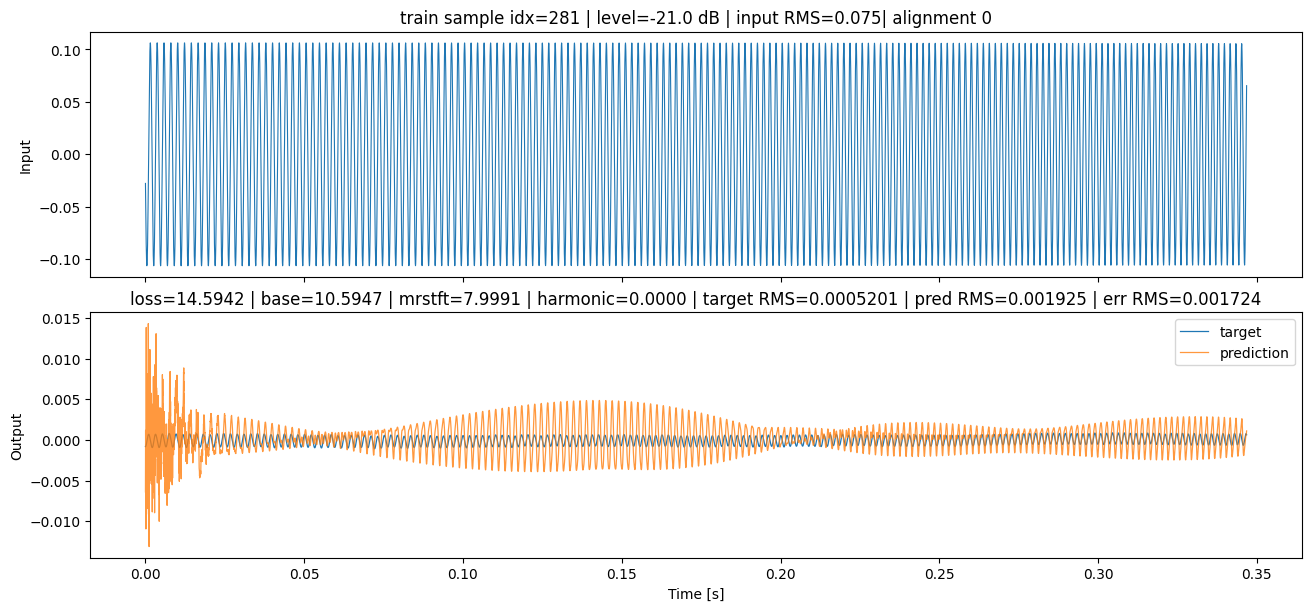

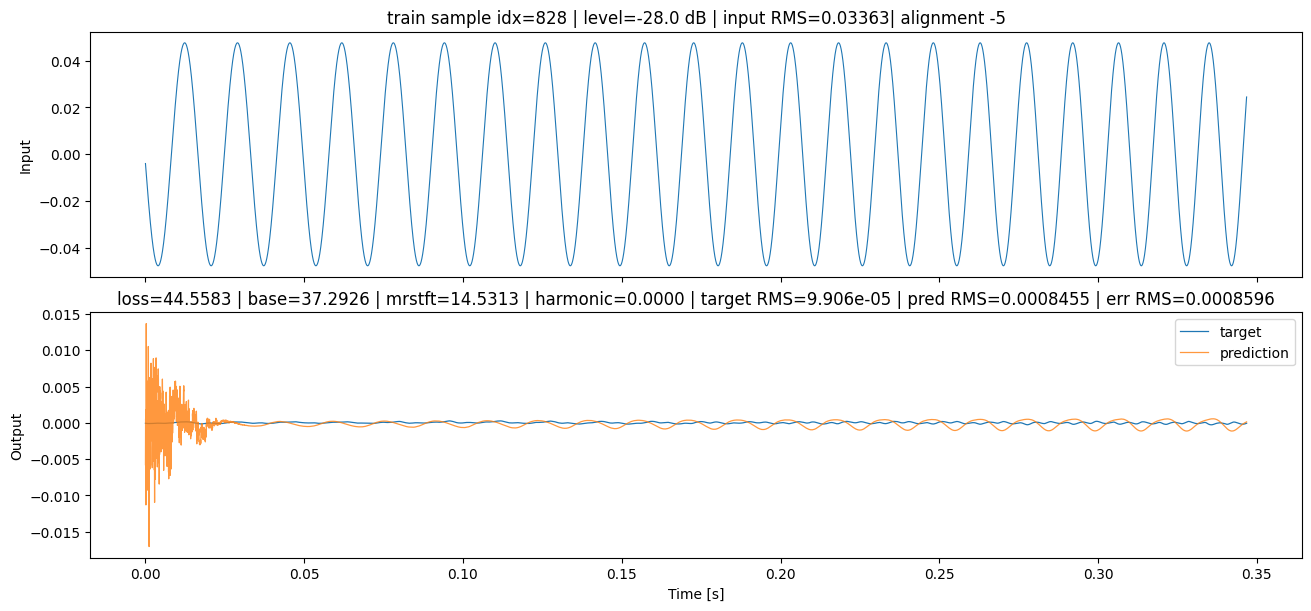

In [32]:
plot_random_dataset_samples(
    ds,
    model,
    split="train",
    #level_db=[-9, -10,-11],
    #idx_range=(0,3),
    n_samples=3,
    sample_rate=sr,
    device=device,
    trim_start=model.receptive_field,
)


In [ ]:
import json
import shutil
from pathlib import Path
from dataclasses import asdict

def save_training_run(
    model,
    optimizer,
    scheduler,
    run_root,
    *,
    mode,
    reference_level_db,
    filter_config,
    model_params,
    training_params,
    data_params,
    history_rows,
    final_epoch,
    best_epoch=None,
    best_val_loss=None,
    device=None,
):
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    filter_name = filter_config.mode
    ref_name = f"ref{reference_level_db:g}dB".replace("-", "m").replace(".", "p")

    run_name = f"{mode}_{ref_name}_{filter_name}_{timestamp}"
    run_dir = Path(run_root) / run_name
    run_dir.mkdir(parents=True, exist_ok=False)

    final_checkpoint = {
        "epoch": int(final_epoch),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "model_params": model_params,
        "training_params": training_params,
        "data_params": data_params,
        "history_rows": history_rows,
        "best_epoch": best_epoch,
        "best_val_loss": None if best_val_loss is None else float(best_val_loss),
    }

    torch.save(final_checkpoint, run_dir / "final_model.pt")

    metadata = {
        "run_name": run_name,
        "saved_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
        "final_epoch": int(final_epoch),
        "best_epoch": best_epoch,
        "best_val_loss": None if best_val_loss is None else float(best_val_loss),
        "device": None if device is None else str(device),
        "model_params": model_params,
        "training_params": training_params,
        "data_params": data_params,
    }

    with open(run_dir / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    with open(run_dir / "history.json", "w", encoding="utf-8") as f:
        json.dump(history_rows, f, indent=2)

    best_path = Path("real_mvp_dump/best_model.pt")
    if best_path.exists():
        shutil.copy2(best_path, run_dir / "best_model.pt")

    print(f"Saved training run to: {run_dir}")
    return run_dir


run_dir = save_training_run(
    model,
    optimizer,
    scheduler,
    "real_mvp_dump/runs",
    mode=ds.target_str,
    reference_level_db=-34.0,
    filter_config=filter_config,
    model_params={
        "n_blocks": N_BLOCKS,
        "kernel_size": KERNEL_SIZE,
        "channels": CHANNELS,
        "input_channels": 1,
        "sr": sr,
    },
    training_params={
        "segment_length_ms": SEG_LENGTH_MS,
        "batch_size": BATCH_SIZE,
        "epochs_requested": EPOCHS,
        "lr": LR,
        "early_stopping": EARLY_STOPPING,
    },
    data_params={
        "target_str": ds.target_str,
        "reference_pair": ds.reference_pair.key,
        "reference_level_db": ds.reference_pair.level_db,
        "filter_config": asdict(filter_config),
        "train_pairs": [pair.key for pair in ds.train_pairs],
        "val_pairs": [pair.key for pair in ds.val_pairs],
        "test_pairs": [pair.key for pair in ds.test_pairs],
        "train_segments": len(ds.train),
        "val_segments": len(ds.val),
        "test_segments": len(ds.test),
    },
    history_rows=history_rows,
    final_epoch=epoch,
    best_epoch=best_epoch,
    best_val_loss=best_val_loss,
    device=device,
)


Saved training run to: real_mvp_dump\runs\residual_refm34dB_highpass_20260511_160437


In [ ]:
from scaleaudio.training.outputs import save_loss_curve, save_training_diagnostics
from scaleaudio.inference import select_device

output_dir = "real_mvp_dump/"
#save_loss_curve(train_curve, val_curve,"real_mvp_dump/loss_curve.png")

#save_training_diagnostics(history_rows, output_dir + "training_diagnostics.png")
print(f"\n  Loss-Kurve gespeichert: {output_dir +'loss_curve.png'}")

print("\n[5/5] Test-Evaluation...")
device = select_device()
model = MicroTCN(
    n_blocks=N_BLOCKS,
    kernel_size=KERNEL_SIZE,
    channels=CHANNELS,
    input_channels=1,
    sr=sr,
).to(device)
checkpoint = torch.load(output_dir + "best_model.pt", map_location=device)
model.load_state_dict(checkpoint)
model.eval()

eval_loader = test_loader if len(ds.test) > 0 else val_loader
eval_split = "test" if len(ds.test) > 0 else "val"
if eval_split == "val":
    print("  ds.test is empty; using validation split for post-training evaluation.")

test_summary = evaluate_model(
    model,
    eval_loader,
    device,
    sample_rate=sr,
    return_breakdown=True,
)
print(
    f"\n  {eval_split.title()} Loss: {test_summary['total']:.5f} | "
    f"base {test_summary['base']:.5f} | "
    f"mrstft {test_summary['mrstft']:.5f} | "
    f"harmonic {test_summary['harmonic']:.5f}"
)

input_batch, target_batch = next(iter(eval_loader))
with torch.no_grad():
    pred_batch = model(input_batch.to(device)).cpu()

# Evaluation

In [ ]:
def predict_full(
    model: MicroTCN,
    input_signal: np.ndarray,
    device: torch.device,
    level_db: float | None = None,
) -> np.ndarray:
    x = torch.from_numpy(input_signal).unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        y = model(x).squeeze().cpu().numpy()
    return np.asarray(y, dtype=np.float32)


def _db20(value, eps=1e-12):
    return float(20.0 * np.log10(float(value) + eps))


def _nearest_amplitude(freqs, mag, freq_hz):
    if freq_hz is None or not np.isfinite(freq_hz) or freq_hz <= 0 or freq_hz >= freqs[-1]:
        return 0.0
    idx = int(np.argmin(np.abs(freqs - freq_hz)))
    lo = max(0, idx - 1)
    hi = min(len(mag), idx + 2)
    return float(np.max(mag[lo:hi]))


def _spectrum(signal, sample_rate, n_fft=None):
    x = np.asarray(signal, dtype=np.float64).reshape(-1)
    x = x - np.mean(x)
    if n_fft is None:
        n_fft = int(2 ** np.ceil(np.log2(max(len(x), 1024))))
    window = np.hanning(len(x))
    spec = np.fft.rfft(x * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sample_rate)
    mag = np.abs(spec)
    return freqs, mag


def _find_tone_frequencies(signal, sample_rate, max_freq=None, min_spacing_hz=40.0):
    freqs, mag = _spectrum(signal, sample_rate)
    max_freq = max_freq or min(sample_rate * 0.45, 20000.0)
    mask = (freqs >= 20.0) & (freqs <= max_freq)
    candidate_idx = np.where(mask)[0]
    if len(candidate_idx) == 0:
        return None, None

    ordered = candidate_idx[np.argsort(mag[candidate_idx])[::-1]]
    chosen = []
    for idx in ordered:
        freq = float(freqs[idx])
        if all(abs(freq - prev) >= min_spacing_hz for prev in chosen):
            chosen.append(freq)
        if len(chosen) == 2:
            break

    if not chosen:
        return None, None
    f1 = min(chosen)
    f2 = max(chosen) if len(chosen) > 1 else None
    return f1, f2


def distortion_profile(
    signal,
    sample_rate,
    *,
    fundamental_freq=None,
    second_freq=None,
    num_harmonics=8,
):
    freqs, mag = _spectrum(signal, sample_rate)
    nyquist = sample_rate / 2.0
    f1 = fundamental_freq
    f2 = second_freq
    if f1 is None:
        f1, f2 = _find_tone_frequencies(signal, sample_rate)

    f1_amp = _nearest_amplitude(freqs, mag, f1)
    harmonic_amps = []
    harmonic_db = {}
    for harmonic in range(2, num_harmonics + 1):
        harmonic_freq = None if f1 is None else harmonic * f1
        if harmonic_freq is None or harmonic_freq >= nyquist:
            amp = 0.0
        else:
            amp = _nearest_amplitude(freqs, mag, harmonic_freq)
        harmonic_amps.append(amp)
        harmonic_db[f"h{harmonic}_db"] = _db20(amp / (f1_amp + 1e-12))

    thd = np.sqrt(np.sum(np.square(harmonic_amps))) / (f1_amp + 1e-12)

    imd_products = {}
    imd_amps = []
    if f1 is not None and f2 is not None and abs(f2 - f1) > 1.0:
        product_freqs = {
            "f2_minus_f1": abs(f2 - f1),
            "f1_plus_f2": f1 + f2,
            "2f1_minus_f2": abs(2.0 * f1 - f2),
            "2f2_minus_f1": abs(2.0 * f2 - f1),
            "2f1_plus_f2": 2.0 * f1 + f2,
            "2f2_plus_f1": 2.0 * f2 + f1,
        }
        tone_ref = np.sqrt(
            f1_amp**2 + _nearest_amplitude(freqs, mag, f2) ** 2
        )
        for name, product_freq in product_freqs.items():
            if 20.0 <= product_freq < nyquist:
                amp = _nearest_amplitude(freqs, mag, product_freq)
                imd_products[f"{name}_db"] = _db20(amp / (tone_ref + 1e-12))
                imd_amps.append(amp)
        imd = np.sqrt(np.sum(np.square(imd_amps))) / (tone_ref + 1e-12)
    else:
        imd = np.nan

    return {
        "f1_hz": np.nan if f1 is None else float(f1),
        "f2_hz": np.nan if f2 is None else float(f2),
        "thd_db": _db20(thd),
        "imd_db": np.nan if np.isnan(imd) else _db20(imd),
        **harmonic_db,
        **imd_products,
    }


def evaluate_distortion_model(
    model,
    loader,
    device,
    sample_rate,
    *,
    split_name="test",
    num_harmonics=8,
    max_batches=None,
):
    model.eval()
    rows = []
    rf = getattr(model, "receptive_field", 0)
    segment_idx = 0

    with torch.no_grad():
        for batch_idx, (input_batch, target_batch) in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break
            pred_batch = model(input_batch.to(device)).cpu()
            target_batch = target_batch.cpu()
            input_batch = input_batch.cpu()

            pred_np = pred_batch[..., rf:].numpy()
            target_np = target_batch[..., rf:].numpy()
            input_np = input_batch[..., rf:].numpy()

            for item_idx in range(pred_np.shape[0]):
                drive = input_np[item_idx, 0]
                target = target_np[item_idx, 0]
                pred = pred_np[item_idx, 0]
                error = target - pred

                f1, f2 = _find_tone_frequencies(drive, sample_rate)
                target_profile = distortion_profile(
                    target,
                    sample_rate,
                    fundamental_freq=f1,
                    second_freq=f2,
                    num_harmonics=num_harmonics,
                )
                pred_profile = distortion_profile(
                    pred,
                    sample_rate,
                    fundamental_freq=f1,
                    second_freq=f2,
                    num_harmonics=num_harmonics,
                )
                error_profile = distortion_profile(
                    error,
                    sample_rate,
                    fundamental_freq=f1,
                    second_freq=f2,
                    num_harmonics=num_harmonics,
                )

                row = {
                    "split": split_name,
                    "segment": segment_idx,
                    "f1_hz": target_profile["f1_hz"],
                    "f2_hz": target_profile["f2_hz"],
                    "target_thd_db": target_profile["thd_db"],
                    "pred_thd_db": pred_profile["thd_db"],
                    "error_thd_db": error_profile["thd_db"],
                    "thd_abs_error_db": abs(pred_profile["thd_db"] - target_profile["thd_db"]),
                    "target_imd_db": target_profile["imd_db"],
                    "pred_imd_db": pred_profile["imd_db"],
                    "error_imd_db": error_profile["imd_db"],
                    "imd_abs_error_db": abs(pred_profile["imd_db"] - target_profile["imd_db"])
                    if np.isfinite(pred_profile["imd_db"]) and np.isfinite(target_profile["imd_db"])
                    else np.nan,
                }
                for harmonic in range(2, num_harmonics + 1):
                    key = f"h{harmonic}_db"
                    row[f"target_{key}"] = target_profile[key]
                    row[f"pred_{key}"] = pred_profile[key]
                    row[f"h{harmonic}_abs_error_db"] = abs(pred_profile[key] - target_profile[key])
                rows.append(row)
                segment_idx += 1

    if not rows:
        raise ValueError(f"No segments available for {split_name} distortion evaluation.")

    summary = {
        "split": split_name,
        "segments": len(rows),
        "mean_target_thd_db": float(np.nanmean([r["target_thd_db"] for r in rows])),
        "mean_pred_thd_db": float(np.nanmean([r["pred_thd_db"] for r in rows])),
        "mean_thd_abs_error_db": float(np.nanmean([r["thd_abs_error_db"] for r in rows])),
        "mean_target_imd_db": float(np.nanmean([r["target_imd_db"] for r in rows])),
        "mean_pred_imd_db": float(np.nanmean([r["pred_imd_db"] for r in rows])),
        "mean_imd_abs_error_db": float(np.nanmean([r["imd_abs_error_db"] for r in rows])),
    }
    return rows, summary


def plot_distortion_summary(rows, summary, num_harmonics=8):
    labels = ["THD", "IMD"]
    target = [summary["mean_target_thd_db"], summary["mean_target_imd_db"]]
    pred = [summary["mean_pred_thd_db"], summary["mean_pred_imd_db"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = np.arange(len(labels))
    width = 0.35
    axes[0].bar(x - width / 2, target, width, label="target")
    axes[0].bar(x + width / 2, pred, width, label="prediction")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel("Distortion ratio (dB)")
    axes[0].set_title(f"Mean Distortion - {summary['split']} split")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend()

    harmonics = list(range(2, num_harmonics + 1))
    harmonic_errors = [
        np.nanmean([r[f"h{harmonic}_abs_error_db"] for r in rows])
        for harmonic in harmonics
    ]
    axes[1].bar([f"H{h}" for h in harmonics], harmonic_errors, color="tab:orange")
    axes[1].set_ylabel("Mean abs error (dB)")
    axes[1].set_title("Harmonic Ratio Error")
    axes[1].grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    return fig


DISTORTION_HARMONICS = 8
distortion_rows, distortion_summary = evaluate_distortion_model(
    model,
    eval_loader,
    device,
    sr,
    split_name=eval_split,
    num_harmonics=DISTORTION_HARMONICS,
)

print("Distortion summary:")
for key, value in distortion_summary.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

try:
    import pandas as pd
    distortion_df = pd.DataFrame(distortion_rows)
    display_cols = [
        "segment",
        "f1_hz",
        "f2_hz",
        "target_thd_db",
        "pred_thd_db",
        "thd_abs_error_db",
        "target_imd_db",
        "pred_imd_db",
        "imd_abs_error_db",
    ]
    display(distortion_df[display_cols].head(12))
except ImportError:
    distortion_df = distortion_rows
    print("Install pandas to view the per-segment distortion table as a DataFrame.")

plot_distortion_summary(distortion_rows, distortion_summary, DISTORTION_HARMONICS)

In [ ]:
%matplotlib inline
selected_pairs = [p for p in pairs if np.isclose(p.level_db, -13)]

test_input_full,_ = sf.read(selected_pairs[0].loopback_path,dtype='float32')
test_output_full,_ = sf.read(selected_pairs[0].mic_path)
test_linref_full,_ = sf.read(selected_pairs[0].linear_reference_path)
test_res_full,_ = sf.read(selected_pairs[0].residual_path)
pred_wav = predict_full(model, test_input_full, device,-13)
#plt.plot(pred_wav)
plt.figure(figsize=(12, 4))
plt.plot(pred_wav, label="prediction", alpha=0.8)
plt.plot(test_linref_full, label="linref", alpha=0.4)
plt.plot(test_res_full, label="measured", alpha=0.6)
plt.legend()
plt.title(f"Predicted vs Measured â€” {selected_pairs[0].key}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()

NameError: name 'selected_pairs' is not defined

In [ ]:
# select pairs with level -29 dB (pairs is a list of Pair objects)
selected_pairs = [p for p in pairs if np.isclose(p.level_db, -13)]
if not selected_pairs:
    raise ValueError("No pairs found with level_db == -29 dB")
selected_pairs

[Pair(key='minus13dB', seq=4, meas=1, level_db=-13.0, loopback_path=WindowsPath('data/prepared/scaled_mic_20260424/refm34_avgmic/input/minus13dB.wav'), mic_path=WindowsPath('data/prepared/scaled_mic_20260424/refm34_avgmic/measured/minus13dB.wav'), linear_reference_path=WindowsPath('data/prepared/scaled_mic_20260424/refm34_avgmic/linear/minus13dB.wav'), residual_path=WindowsPath('data/prepared/scaled_mic_20260424/refm34_avgmic/target/minus13dB.wav'))]